# KNN Demonstration: Predicting Diabetes with Python

In this webinar, we'll use the Pima Indians Diabetes dataset to build a KNN classifier. 
Goals:
- Explore the data
- Preprocess and split
- Tune hyperparameters with GridSearchCV
- Evaluate with cross-validation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)
plt.style.use('ggplot')

In [2]:
#Load the dataset
df = pd.read_csv('diabetes.csv')

#Print the first 5 rows of the dataframe.
df.head()

,Preg,Plas,Pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
#Let's observe the shape of the dataframe.
df.shape

(768, 9)

In [4]:
df.describe(include='all')

,Preg,Plas,Pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Preg    768 non-null    int64  
 1   Plas    768 non-null    int64  
 2   Pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df['class'].value_counts()

class
0    500
1    268
Name: count, dtype: int64

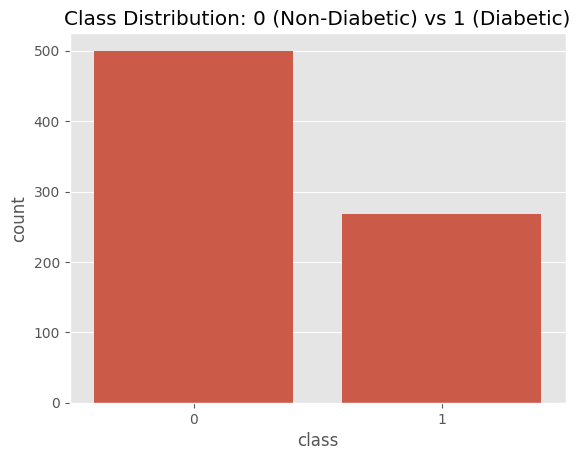

In [7]:
# Visualize class distribution
import seaborn as sns
sns.countplot(x='class', data=df)
plt.title('Class Distribution: 0 (Non-Diabetic) vs 1 (Diabetic)')
plt.show()

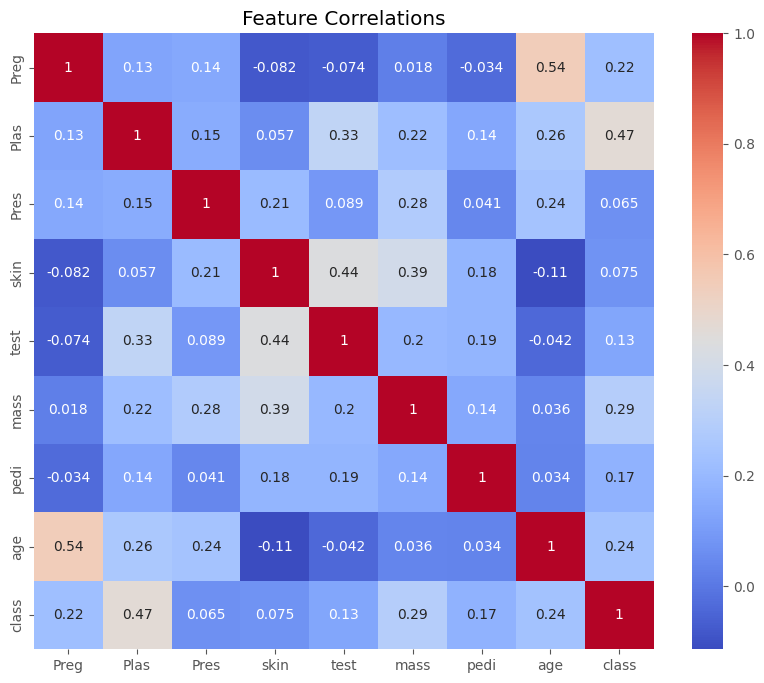

In [8]:
# Correlation matrix to see feature relationships
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

In [53]:
df['class'].value_counts(normalize=True) * 100

class
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [9]:
# Why scale? KNN measures distances—features like glucose (high range) would dominate without it.
# Scale features (important for KNN!)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('class', axis=1))
X = X_scaled  # Replace original X
y = df['class'].values

#importing train_test_split
from sklearn.model_selection import train_test_split

#Split the dataset into train and test with stratification
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42, stratify=y)

In [54]:
y_train

array([1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,

In [55]:
print("Train classes:", pd.Series(y_train).value_counts(normalize=True) * 100)
print("Test classes:", pd.Series(y_test).value_counts(normalize=True) * 100)

Train classes: 0    64.878049
1    35.121951
Name: proportion, dtype: float64
Test classes: 0    66.013072
1    33.986928
Name: proportion, dtype: float64


In [56]:
#import KNeighborsClassifier
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier

#Setup arrays to store training and test accuracies
neighbors = np.arange(1,50)
train_accuracy =np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i,k in enumerate(neighbors):
    print(f"Training KNN with k={k}")
    #Setup a knn classifier with k neighbors
    model = KNeighborsClassifier(n_neighbors=k)

    #Fit the model
    model.fit(X_train, y_train)

    #Compute accuracy on the training set
    train_accuracy[i] = model.score(X_train, y_train)

    #Compute accuracy on the test set
    test_accuracy[i] = model.score(X_test, y_test)
    
    cv_results = cross_validate(model, X_train, y_train, cv=10)
    sorted(cv_results.keys())
    print(cv_results['test_score'])
    print("\n\n")

Training KNN with k=1
[0.66129032 0.74193548 0.62903226 0.67741935 0.62903226 0.75409836
 0.6557377  0.68852459 0.72131148 0.73770492]



Training KNN with k=2
[0.69354839 0.74193548 0.69354839 0.67741935 0.66129032 0.68852459
 0.68852459 0.7704918  0.70491803 0.73770492]



Training KNN with k=3
[0.67741935 0.75806452 0.70967742 0.70967742 0.75806452 0.70491803
 0.63934426 0.80327869 0.67213115 0.78688525]



Training KNN with k=4
[0.69354839 0.75806452 0.67741935 0.74193548 0.72580645 0.72131148
 0.63934426 0.7704918  0.70491803 0.7704918 ]



Training KNN with k=5
[0.66129032 0.77419355 0.72580645 0.74193548 0.75806452 0.73770492
 0.6557377  0.7704918  0.70491803 0.73770492]



Training KNN with k=6
[0.69354839 0.77419355 0.67741935 0.72580645 0.77419355 0.72131148
 0.6557377  0.7704918  0.67213115 0.78688525]



Training KNN with k=7
[0.69354839 0.77419355 0.72580645 0.67741935 0.80645161 0.72131148
 0.63934426 0.7704918  0.68852459 0.78688525]



Training KNN with k=8
[0.72580645 

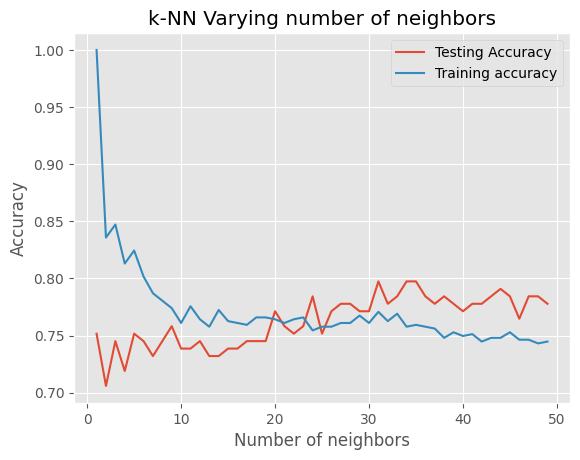

In [41]:
#Generate plot
plt.title('k-NN Varying number of neighbors')
plt.plot(neighbors, test_accuracy, label='Testing Accuracy')
plt.plot(neighbors, train_accuracy, label='Training accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.show()

## Summary of steps to use a classification model

1. Choose and Train a Classification Model:
   model = ....
   model.fit(X_train, y_train)
   
3. Make Predictions
   y_pred = model.predict(X_test)
   
5. Evaluate the Model (based on the predictions - calculate the scores like accuracy)
   model.score(X_test,y_test)

   Other ways to evaluate:
   Confusion matrix
   Classification report

### Confusion Matrix

In [42]:
#Setup a knn classifier with k neighbors
model = KNeighborsClassifier(n_neighbors=25)

#Fit the model
model.fit(X_train,y_train)

#Get accuracy. Note: In case of classification algorithms score method represents accuracy.
model.score(X_test,y_test)

0.7516339869281046

In [43]:
#import confusion_matrix
from sklearn.metrics import confusion_matrix

#let us get the predictions using the classifier we had fit above
y_pred = model.predict(X_test)

confusion_matrix(y_test,y_pred)

array([[87, 14],
       [24, 28]])

In [44]:
pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
Actual,,,
0,87,14,101
1,24,28,52
All,111,42,153


### Classification report
#### Classification report is a tool used to evaluate the performance of a classification model. It provides a summary of key metrics for each class in the target variable.

In [45]:
#import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))
# Support: The number of actual occurrences of each class in the dataset. It indicates how many samples from each class are present in the test set.


              precision    recall  f1-score   support

           0       0.78      0.86      0.82       101
           1       0.67      0.54      0.60        52

    accuracy                           0.75       153
   macro avg       0.73      0.70      0.71       153
weighted avg       0.74      0.75      0.74       153



## Hyperparameter Tuning
You may want to tune the model’s hyperparameters to improve performance. This can be done using GridSearchCV.

In [ ]:
#import GridSearchCV
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

#In case of classifier like knn the parameter to be tuned is n_neighbors
param_grid = {'n_neighbors':np.arange(1,50)}

model = KNeighborsClassifier()
model_cv= GridSearchCV(model,param_grid,cv=5)
model_cv.fit(X_train, y_train)  # Use X_train, y_train

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])})

In [48]:
model_cv.best_score_

np.float64(0.7674796747967481)

In [49]:
model_cv.best_params_

{'n_neighbors': np.int64(23)}

Test Accuracy: 0.7581699346405228
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       101
           1       0.67      0.58      0.62        52

    accuracy                           0.76       153
   macro avg       0.73      0.71      0.72       153
weighted avg       0.75      0.76      0.75       153



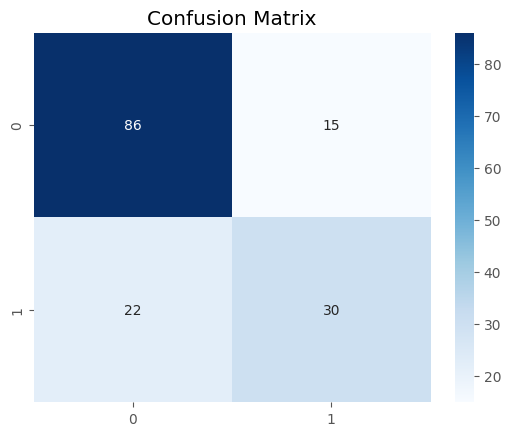

In [50]:
# Best model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

best_model = model_cv.best_estimator_
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Homework task: Crossvalidation

In [ ]:
from sklearn.model_selection import KFold, StratifiedKFold

# Initialize a classifier (RandomForest in this case)
model = KNeighborsClassifier(n_neighbors=7)

# Define KFold cross-validation
kf = KFold(n_splits=5, shuffle=True)  # 5-fold cross-validation with shuffling

# Store cross-validation results
cv_scores = []

# Perform cross-validation manually
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)  # Evaluate on the test fold
    cv_scores.append(score)

# Output the cross-validation scores
print(f'Cross-validation scores for each fold: {cv_scores}')
print(f'Average cross-validation score: {np.mean(cv_scores):.2f}')